In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/weather-data2000-2023/South_Africa_weather_data.csv
/kaggle/input/weather-data2000-2023/weather_data_top100.csv
/kaggle/input/weather-data2000-2023/Argentina_weather_data.csv
/kaggle/input/weather-data2000-2023/Vietnam_weather_data.csv
/kaggle/input/weather-data2000-2023/Russia_weather_data.csv
/kaggle/input/weather-data2000-2023/India_weather_data.csv
/kaggle/input/weather-data2000-2023/United_States_weather_data.csv
/kaggle/input/weather-data2000-2023/Italy_weather_data.csv
/kaggle/input/weather-data2000-2023/Philippines_weather_data.csv
/kaggle/input/weather-data2000-2023/Thailand_weather_data.csv
/kaggle/input/weather-data2000-2023/Turkey_weather_data.csv
/kaggle/input/weather-data2000-2023/Pakistan_weather_data.csv
/kaggle/input/weather-data2000-2023/Brazil_weather_data.csv
/kaggle/input/weather-data2000-2023/United_Kingdom_weather_data.csv
/kaggle/input/weather-data2000-2023/Myanmar_weather_data.csv
/kaggle/input/weather-data2000-2023/Tanzania_weather_data.csv
/kagg

In [2]:
# Lista com todas as bases disponíveis
path_countries = ['/kaggle/input/weather-data2000-2023/Argentina_weather_data.csv',
'/kaggle/input/weather-data2000-2023/Vietnam_weather_data.csv', '/kaggle/input/weather-data2000-2023/Russia_weather_data.csv',
'/kaggle/input/weather-data2000-2023/India_weather_data.csv', '/kaggle/input/weather-data2000-2023/United_States_weather_data.csv',
'/kaggle/input/weather-data2000-2023/Italy_weather_data.csv', '/kaggle/input/weather-data2000-2023/Philippines_weather_data.csv',
'/kaggle/input/weather-data2000-2023/Thailand_weather_data.csv', '/kaggle/input/weather-data2000-2023/Turkey_weather_data.csv',
'/kaggle/input/weather-data2000-2023/Pakistan_weather_data.csv', '/kaggle/input/weather-data2000-2023/Brazil_weather_data.csv',
'/kaggle/input/weather-data2000-2023/United_Kingdom_weather_data.csv', '/kaggle/input/weather-data2000-2023/Myanmar_weather_data.csv',
'/kaggle/input/weather-data2000-2023/Tanzania_weather_data.csv', '/kaggle/input/weather-data2000-2023/Spain_weather_data.csv',
'/kaggle/input/weather-data2000-2023/Indonesia_weather_data.csv', '/kaggle/input/weather-data2000-2023/France_weather_data.csv',
'/kaggle/input/weather-data2000-2023/Mexico_weather_data.csv', '/kaggle/input/weather-data2000-2023/Nigeria_weather_data.csv',
'/kaggle/input/weather-data2000-2023/China_weather_data.csv']

In [3]:
# Vamos criar um dicionário para podermos carregar os conjuntos
# Usando a notação da lista, vamos definir o nome dos itens no dicionario
# Com os nomes dos países da base

dfs = {}

for path in path_countries:
    country = path.split('/')[-1].split('_')[0]
    dfs[f'{country}'] = pd.read_csv(path)

In [4]:
# Vamos ver os valores das chaves no dicionario
# Confirmando que salvamos os nomes dos países
print(dfs.keys())

dict_keys(['Argentina', 'Vietnam', 'Russia', 'India', 'United', 'Italy', 'Philippines', 'Thailand', 'Turkey', 'Pakistan', 'Brazil', 'Myanmar', 'Tanzania', 'Spain', 'Indonesia', 'France', 'Mexico', 'Nigeria', 'China'])


In [5]:
# Vamos apresentar as informações contidas em um dos conjuntos

dfs['China']

,Country,Date,Temp_Max,Temp_Min,Temp_Mean,Precipitation_Sum,Windspeed_Max,Windgusts_Max,Sunshine_Duration
0,China,01-01-2000,2.5,-6.4,-2.1,0.0,11.5,21.6,31290.29
1,China,02-01-2000,8.0,-7.8,-1.0,0.0,11.2,20.5,31514.88
2,China,03-01-2000,8.5,-4.9,0.8,0.0,10.8,24.1,31470.55
3,China,04-01-2000,3.2,-6.4,-2.0,0.0,10.2,23.0,31518.97
4,China,05-01-2000,-5.1,-10.1,-7.2,0.0,15.3,32.4,30848.45
...,...,...,...,...,...,...,...,...,...
8761,China,27-12-2023,5.9,-5.9,-1.1,0.0,9.9,14.8,31103.88
8762,China,28-12-2023,4.7,-8.2,-1.8,0.0,10.6,19.4,30665.14
8763,China,29-12-2023,5.6,-6.1,-0.4,0.0,13.3,24.5,31081.96
8764,China,30-12-2023,6.3,-4.6,-0.1,0.0,11.6,24.1,31214.93


# Vamos nos focar no **Brasil** daqui em diante

In [6]:
dfs['Brazil']

,Country,Date,Temp_Max,Temp_Min,Temp_Mean,Precipitation_Sum,Windspeed_Max,Windgusts_Max,Sunshine_Duration
0,Brazil,01-01-2000,26.5,21.8,23.7,15.7,8.8,24.8,10559.94
1,Brazil,02-01-2000,27.2,21.8,23.5,11.7,12.7,32.8,14654.83
2,Brazil,03-01-2000,26.6,21.6,23.3,20.9,15.0,38.2,16619.55
3,Brazil,04-01-2000,24.0,21.3,22.3,12.0,13.4,29.2,7564.03
4,Brazil,05-01-2000,27.8,21.1,23.7,16.6,13.0,31.3,27173.35
...,...,...,...,...,...,...,...,...,...
8761,Brazil,27-12-2023,35.7,22.6,29.1,0.0,8.3,23.8,43976.89
8762,Brazil,28-12-2023,36.5,23.6,30.1,0.0,11.9,29.2,43970.77
8763,Brazil,29-12-2023,35.0,24.6,28.9,0.6,10.8,28.1,38982.19
8764,Brazil,30-12-2023,34.1,24.2,27.3,12.2,12.3,31.0,33460.34


In [7]:
# Não precisamos da coluna que tem o nome do país

dfs["Brazil"].drop('Country', axis=1, inplace=True)

In [8]:
# Ajustando a data para o formato que encontramos no conjunto

dfs["Brazil"]['Date'] = pd.to_datetime(dfs["Brazil"]["Date"], format="%d-%m-%Y")

In [9]:
# Vamos ordenar o conjunto pela data

dfs["Brazil"] = dfs["Brazil"].sort_values("Date")
dfs["Brazil"].set_index("Date", inplace=True)

<Axes: xlabel='Date'>

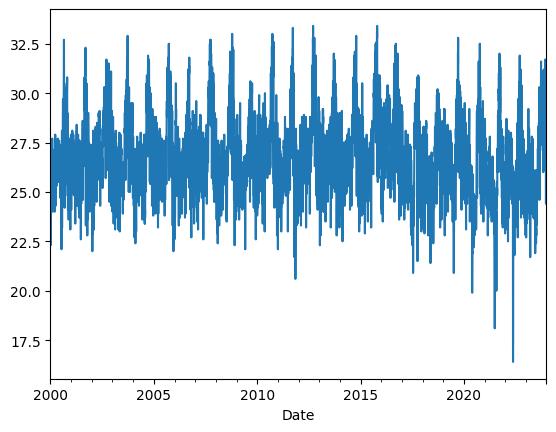

In [10]:
# Vamos focar em analisar apenas a média da temperatura

dfs["Brazil"]["Temp_Mean"].plot()

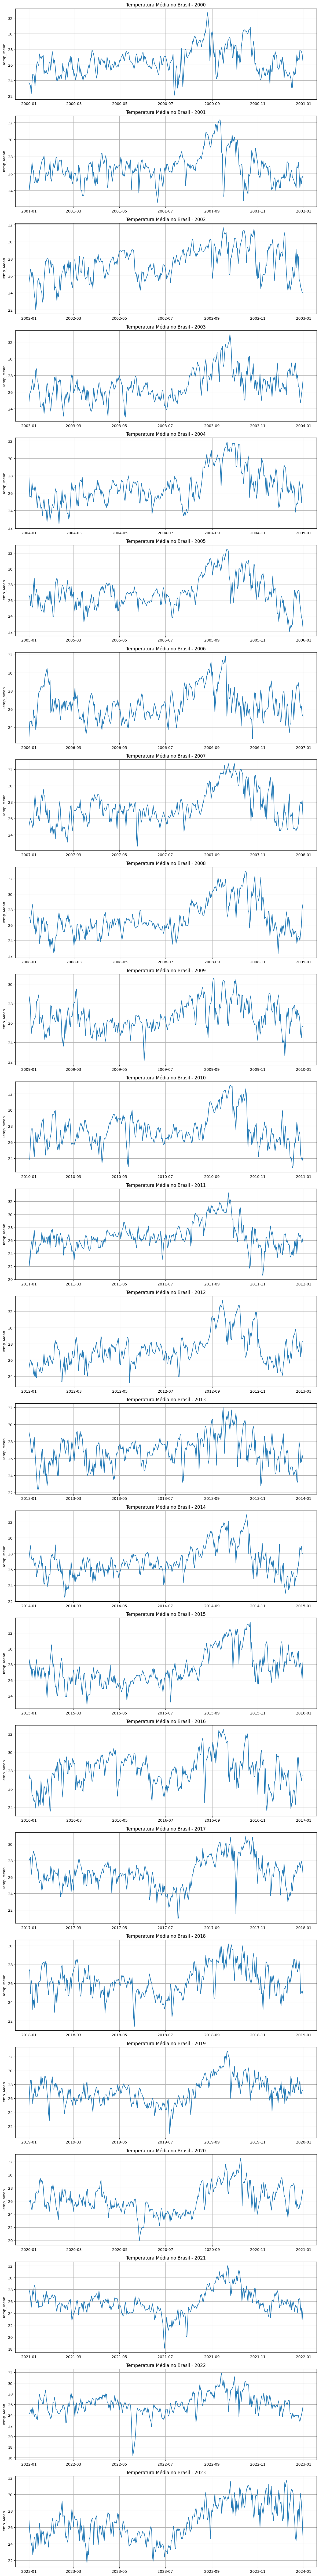

In [11]:
# Apresentamos gráficos em linha das variações da média ao logo dos anos
# Cada linha se refere a um único ano

years = dfs["Brazil"].index.year.unique()
n_years = len(years)

fig, axes = plt.subplots(n_years, 1, figsize=(12, 4 * n_years), sharex=False)

for i, year in enumerate(years):
    df_year = dfs["Brazil"][dfs["Brazil"].index.year == year]
    axes[i].plot(df_year.index, df_year["Temp_Mean"])
    axes[i].set_title(f"Temperatura Média no Brasil - {year}")
    axes[i].set_ylabel("Temp_Mean")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

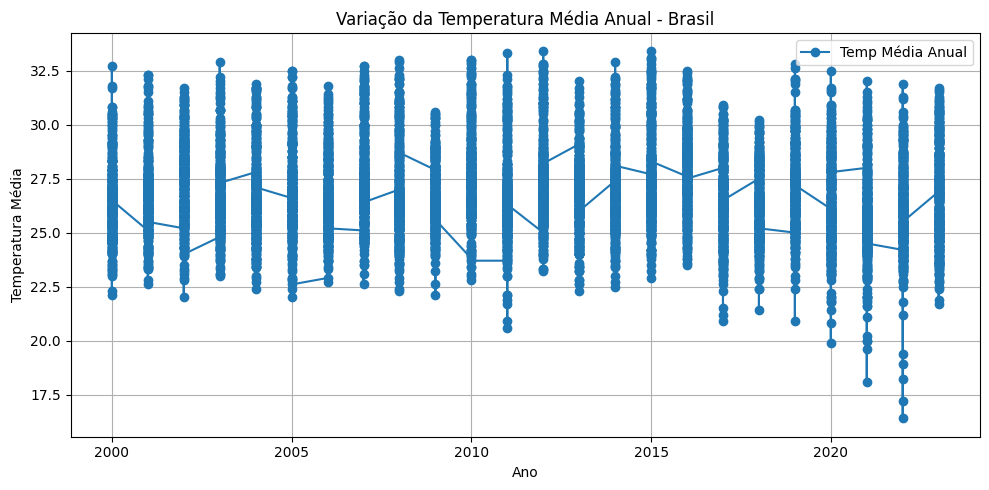

In [12]:
# A ideia aqui é ver e poder comparar visualmente as mudanças nas médias
# Notamos que em alguns anos a média diminui muito e em outros aumentamos

temp_by_year = dfs["Brazil"]["Temp_Mean"]
temp_by_year.index = temp_by_year.index.year

plt.figure(figsize=(10, 5))
plt.plot(temp_by_year.index, temp_by_year.values, marker='o', label='Temp Média Anual')
plt.title("Variação da Temperatura Média Anual - Brasil")
plt.xlabel("Ano")
plt.ylabel("Temperatura Média")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Usando uma regressão linear 


In [13]:
df = dfs["Brazil"][['Temp_Mean']].copy()
df.index = pd.to_datetime(df.index)

In [14]:
df

,Temp_Mean
Date,
2000-01-01,23.7
2000-01-02,23.5
2000-01-03,23.3
2000-01-04,22.3
2000-01-05,23.7
...,...
2023-12-27,29.1
2023-12-28,30.1
2023-12-29,28.9


In [15]:
df.shape

(8766, 1)

In [16]:
"""
Futuramente vamos tentar prever as temperaturas, para isso vamos fazer:
O uso do shift para voltar no tempo e tentar prever a próxima temp, inicialmente 
vou usar apenas 2 (dias) para termos uma ideia do comportamento da regressão.
Depois vou usar um método para calcular melhor a quantidade de shifts ideais para,
conjunto de dados.
"""

df['lag_1'] = df['Temp_Mean'].shift(1)
df['lag_2'] = df['Temp_Mean'].shift(2)

df = df.dropna()

In [17]:
df.shape

(8764, 3)

In [18]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
tscv = TimeSeriesSplit(n_splits=5)

In [20]:
X = df[['lag_1', 'lag_2']].values
y = df['Temp_Mean'].values

mae_scores, rmse_scores, r2_scores = [], [], []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_scores.append(r2_score(y_test, y_pred))

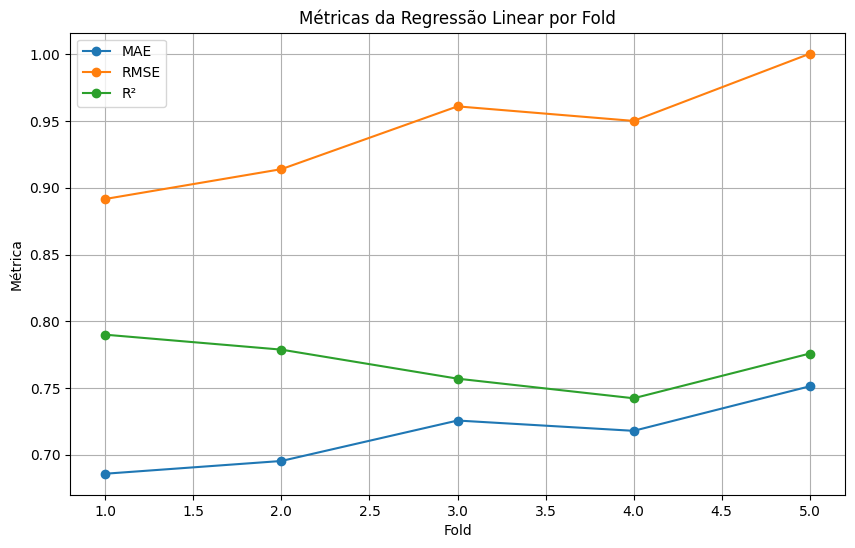

MAE médio: 0.7153
RMSE médio: 0.9434
R² médio: 0.7688


In [21]:
folds = range(1, len(mae_scores) + 1)

plt.figure(figsize=(10,6))
plt.plot(folds, mae_scores, marker='o', label='MAE')
plt.plot(folds, rmse_scores, marker='o', label='RMSE')
plt.plot(folds, r2_scores, marker='o', label='R²')
plt.xlabel('Fold')
plt.ylabel('Métrica')
plt.title('Métricas da Regressão Linear por Fold')
plt.legend()
plt.grid(True)
plt.show()

print(f'MAE médio: {np.mean(mae_scores):.4f}')
print(f'RMSE médio: {np.mean(rmse_scores):.4f}')
print(f'R² médio: {np.mean(r2_scores):.4f}')

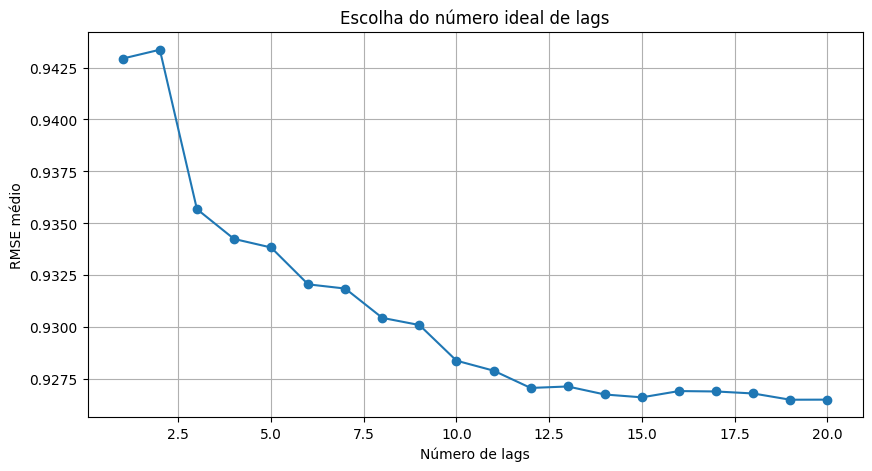

In [22]:
max_lags = 20
rmse_scores = []

for lag in range(1, max_lags+1):
    df = dfs["Brazil"][['Temp_Mean']].copy()
    for i in range(1, lag+1):
        df[f'lag_{i}'] = df['Temp_Mean'].shift(i)
    df = df.dropna()

    X = df.drop(columns=['Temp_Mean']).values
    y = df['Temp_Mean'].values
    
    tscv = TimeSeriesSplit(n_splits=5)
    rmses = []
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmses.append(rmse)
    
    rmse_scores.append(np.mean(rmses))

# Plot do RMSE médio vs número de lags
plt.figure(figsize=(10,5))
plt.plot(range(1, max_lags+1), rmse_scores, marker='o')
plt.xlabel('Número de lags')
plt.ylabel('RMSE médio')
plt.title('Escolha do número ideal de lags')
plt.grid(True)
plt.show()


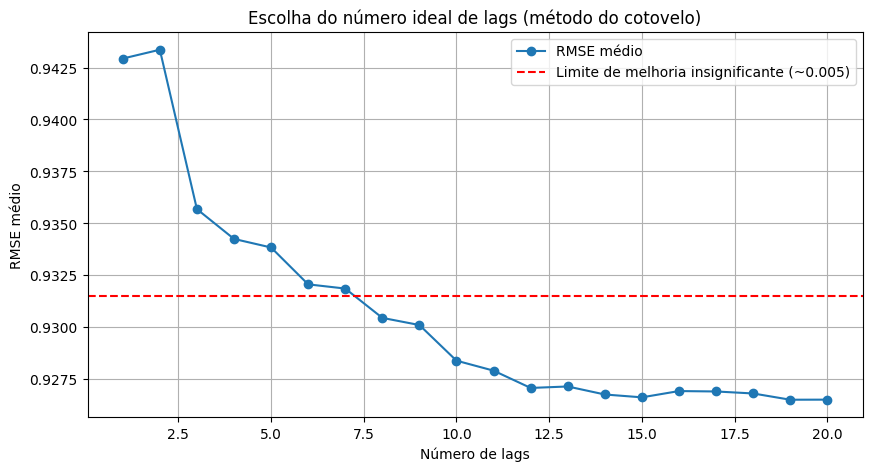

In [23]:
plt.figure(figsize=(10,5))
plt.plot(range(1, max_lags+1), rmse_scores, marker='o', label='RMSE médio')
plt.axhline(y=min(rmse_scores) + 0.005, color='r', linestyle='--', label='Limite de melhoria insignificante (~0.005)')
plt.xlabel('Número de lags')
plt.ylabel('RMSE médio')
plt.title('Escolha do número ideal de lags (método do cotovelo)')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
rmse_scores = np.array(rmse_scores)
rmse_min = np.min(rmse_scores)
tolerancia = 0.005

# Encontra o primeiro lag dentro da faixa aceitável
for lag, rmse in enumerate(rmse_scores, start=1):
    if rmse <= rmse_min + tolerancia:
        print(f"➡️ Cotovelo encontrado em: {lag} lags (RMSE = {rmse:.4f})")
        break

➡️ Cotovelo encontrado em: 8 lags (RMSE = 0.9305)


In [25]:
# Recria DataFrame com 8 lags
df = dfs["Brazil"][['Temp_Mean']].copy()
for i in range(1, 9):  # 1 até 8
    df[f'lag_{i}'] = df['Temp_Mean'].shift(i)

df = df.dropna()

X = df.drop(columns=['Temp_Mean']).values
y = df['Temp_Mean'].values

# TimeSeriesSplit + regressão como antes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)
mae_scores, rmse_scores, r2_scores = [], [], []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_scores.append(r2_score(y_test, y_pred))

print(f"MAE médio (8 lags): {np.mean(mae_scores):.4f}")
print(f"RMSE médio (8 lags): {np.mean(rmse_scores):.4f}")
print(f"R² médio (8 lags): {np.mean(r2_scores):.4f}")


MAE médio (8 lags): 0.7049
RMSE médio (8 lags): 0.9305
R² médio (8 lags): 0.7752
